Univariate Transformer forecasting per bridge

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import os

In [2]:
DATA_PATH = "2017 Monthly Bike Count Totals for East River Bridges"

In [3]:
def load_data():
    dfs = []

    for f in os.listdir(DATA_PATH):
        if f.endswith(".xlsx"):

            df = pd.read_excel(
                os.path.join(DATA_PATH, f),
                header=5,
                usecols="B:K"
            )

            df.columns = df.columns.str.lower()
            df["date"] = pd.to_datetime(df["date"], errors="coerce")
            df = df[df["date"].notna()]

            dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)
    df = df.sort_values("date")
    df = df.reset_index(drop=True)

    return df

In [4]:
df = load_data()

In [5]:
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

In [6]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x

In [8]:
LOOKBACK = 30
EPOCHS = 100
BATCH_SIZE = 8
LR = 0.001
D_MODEL = 64
NHEAD = 4
NUM_LAYERS = 2

In [9]:
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.input_proj = nn.Linear(1, D_MODEL)
        self.pos_encoder = PositionalEncoding(D_MODEL)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL,
            nhead=NHEAD,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS)

        self.fc = nn.Linear(D_MODEL, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = self.fc(x[:, -1, :])
        return x

In [10]:
def train_model(model, loader, criterion, optimizer):
    model.train()
    for X, y in loader:
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output.squeeze(), y)
        loss.backward()
        optimizer.step()

In [11]:
def evaluate(preds, y_test):
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return preds, mae, rmse

In [12]:
def run_transformer(series, bridge_name):
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(series.values.reshape(-1, 1)).flatten()

    X, y = create_sequences(scaled, LOOKBACK)

    split = int(len(X) * 0.7)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    train_ds = TimeSeriesDataset(
        X_train.reshape(-1, LOOKBACK, 1),
        y_train
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    model = TransformerModel()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    for epoch in range(EPOCHS):
        train_model(model, train_loader, criterion, optimizer)

    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X_test.reshape(-1, LOOKBACK, 1), dtype=torch.float32)).numpy().squeeze()

    # inverse scale
    preds = scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
    y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    preds, mae, rmse = evaluate(preds, y_test)

    print(f"\n=== Transformer - {bridge_name} ===")
    print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

    plt.figure()
    plt.plot(y_test, label="Actual")
    plt.plot(preds, label="Predicted")
    plt.title(f"Transformer Forecast - {bridge_name}")
    plt.legend()
    plt.show()


=== Transformer - brooklyn bridge ===
MAE: 565.28, RMSE: 811.01


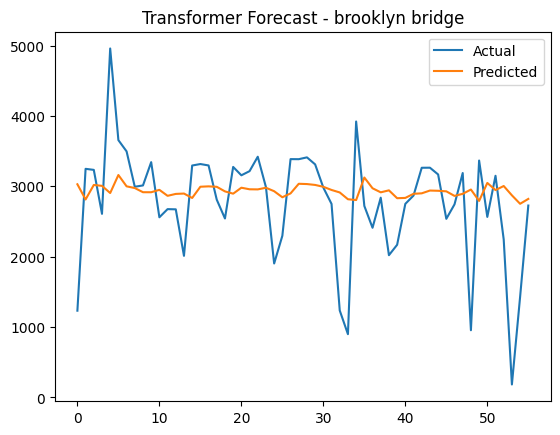


=== Transformer - manhattan bridge ===
MAE: 1336.22, RMSE: 1664.56


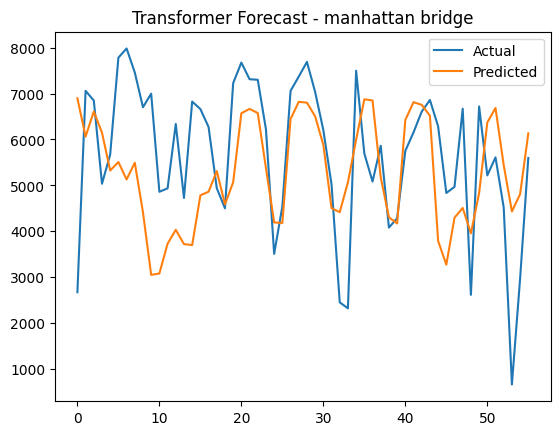


=== Transformer - williamsburg bridge ===
MAE: 1451.87, RMSE: 2057.32


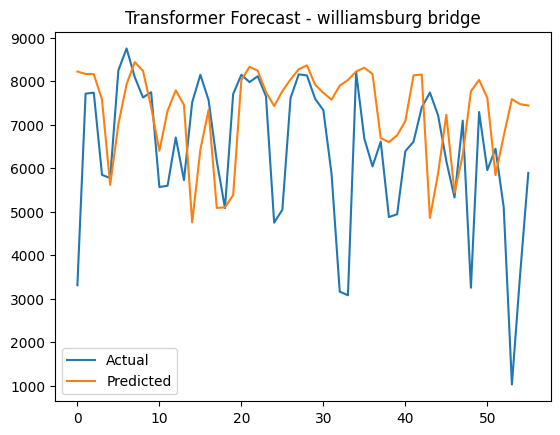


=== Transformer - queensboro bridge ===
MAE: 978.46, RMSE: 1308.98


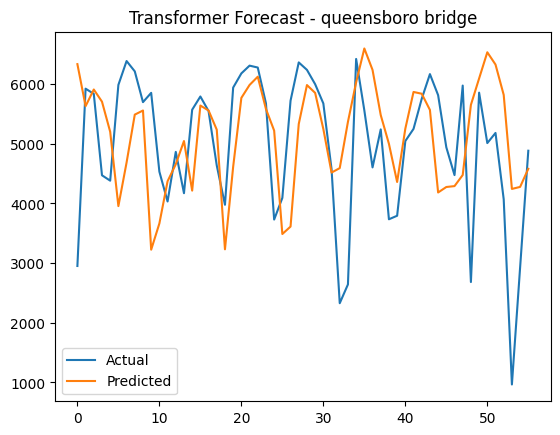

In [13]:
bridges = [
    "brooklyn bridge",
    "manhattan bridge",
    "williamsburg bridge",
    "queensboro bridge"
]

for b in bridges:
    series = df[b].dropna()
    run_transformer(series, b)